Raw EDA Visuals 

We check: 

    1. Histograms for all features
    2. boxplots for Glucose/BMI/BP/Insulin
    3. class balance chart
    4. correlation heatmap
    5. notes on skew and outliers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
diabetes = pd.read_csv("../data/diabetes.csv")

1. Histograms for all features

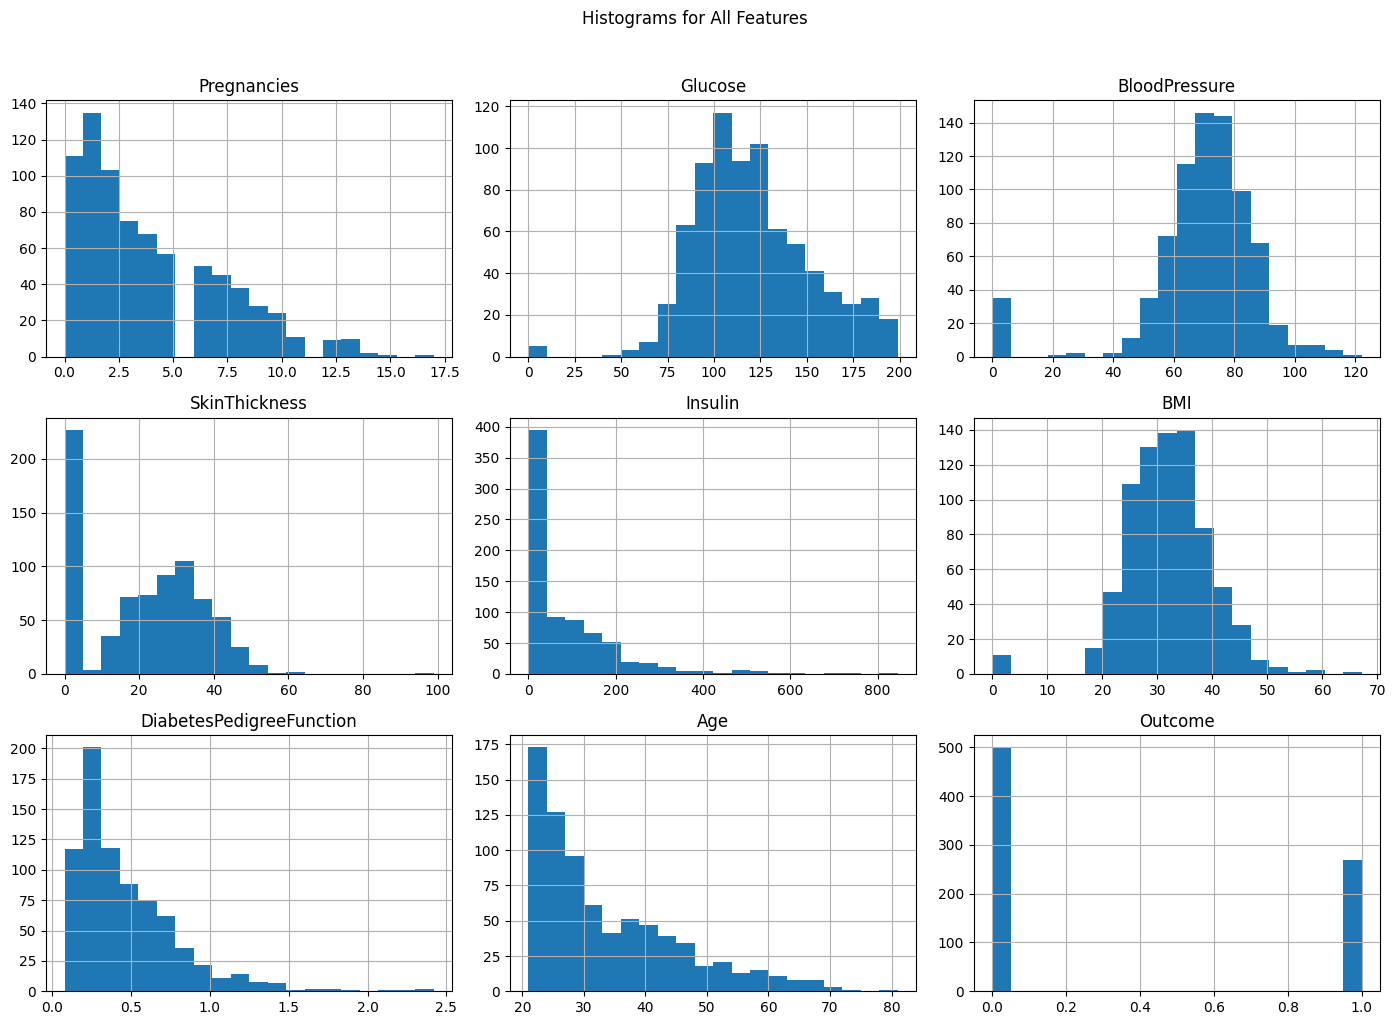

In [4]:
diabetes.hist(figsize=(14, 10), bins=20)
plt.suptitle("Histograms for All Features", y=1.02)
plt.tight_layout()
plt.show()

2. Boxplots for Glucose/BMI/BP/Insulin

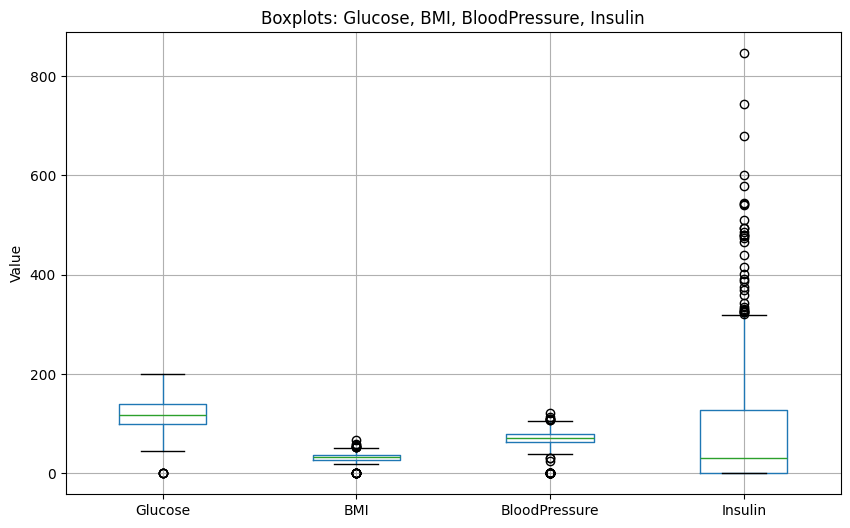

In [5]:
cols_to_boxplot = ['Glucose', 'BMI', 'BloodPressure', 'Insulin']

plt.figure(figsize=(10, 6))
diabetes[cols_to_boxplot].boxplot()
plt.title("Boxplots: Glucose, BMI, BloodPressure, Insulin")
plt.ylabel("Value")
plt.show()

3. Class Balance Chart 

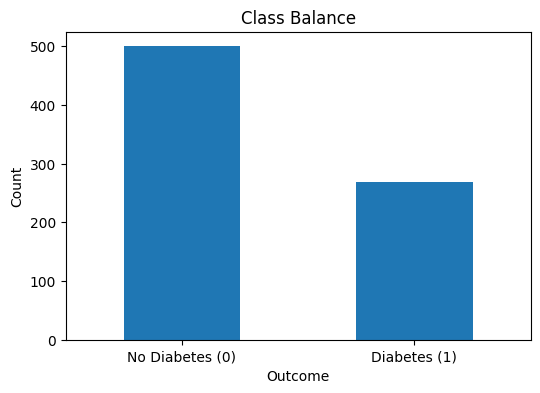

Class counts:
Outcome
0    500
1    268
Name: count, dtype: int64

Class proportions:
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


In [6]:
class_counts = diabetes['Outcome'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
class_counts.plot(kind='bar')
plt.title("Class Balance")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.xticks([0, 1], ['No Diabetes (0)', 'Diabetes (1)'], rotation=0)
plt.show()

print("Class counts:")
print(class_counts)
print("\nClass proportions:")
print(diabetes['Outcome'].value_counts(normalize=True).sort_index())

4. Correlation heatmap

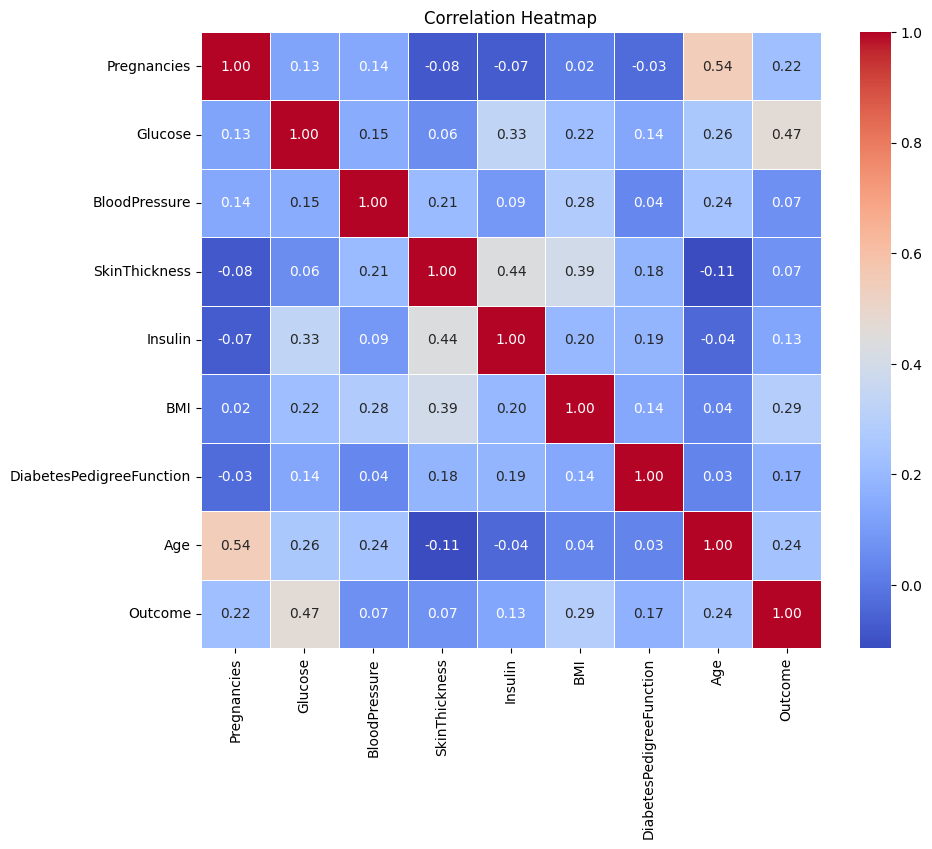

In [7]:
plt.figure(figsize=(10, 8))
corr = diabetes.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

5. Notes on skew and outliers

In [8]:
# Skewness
skewness = diabetes.skew(numeric_only=True).sort_values(ascending=False)
print("\nSkewness by feature:")
print(skewness)

# IQR-based outlier counts
def outlier_count_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

outlier_counts = diabetes.drop(columns=['Outcome']).apply(outlier_count_iqr).sort_values(ascending=False)

print("\nOutlier counts by feature (IQR method):")
print(outlier_counts)


Skewness by feature:
Insulin                     2.272251
DiabetesPedigreeFunction    1.919911
Age                         1.129597
Pregnancies                 0.901674
Outcome                     0.635017
Glucose                     0.173754
SkinThickness               0.109372
BMI                        -0.428982
BloodPressure              -1.843608
dtype: float64

Outlier counts by feature (IQR method):
BloodPressure               45
Insulin                     34
DiabetesPedigreeFunction    29
BMI                         19
Age                          9
Glucose                      5
Pregnancies                  4
SkinThickness                1
dtype: int64
